# Born-projected angular coefficients from POWHEG LHE events

This notebook builds the first complete analysis chain for off-shell $H\to ZZ\to e^+e^-\mu^+\mu^-$ events:

1. read the LHE file with `pylhe`;
2. select only the final-state $e^-$, $e^+$, $\mu^-$, and $\mu^+$ and reconstruct $Z_1$, $Z_2$, and the Higgs candidate from their four-vector sums;
3. remove the color-singlet transverse recoil with the Born projection of [arXiv:2606.11083](https://arxiv.org/abs/2606.11083);
4. construct the angular coordinates and standard four-lepton observables, following the terminology of [arXiv:1208.4018](https://arxiv.org/abs/1208.4018);
5. project the full inclusive symmetric basis through $\ell_{\max}=3$;
6. train a reweighted density-ratio estimator with [`nsbi-common-utils`](https://github.com/iris-hep/nsbi-lhc-toolkit); and
7. compare the learned differential angular coefficient with the direct weighted projection.

Our fixed off-shell convention is $Z_1=Z_{\mu\mu}$ and $Z_2=Z_{ee}$; there is no mass ordering. The harmonic coordinates use the **positively charged** lepton in each $Z$ rest frame. The separately named `theta1_standard` and `theta2_standard` use the negatively charged leptons, as in arXiv:1208.4018.

In [1]:
from pathlib import Path
import sys
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from offshell_angles import (
    angular_modes,
    as_float32_features,
    class_balanced_validation_bce,
    inclusive_angular_coefficients,
    angular_target,
    load_lhe_dataframe,
    prepare_weighted_classification,
    recover_conditional_moment,
    validation_loss_outlier_mask,
)

hep.style.use("ATLAS")
pd.set_option("display.max_columns", 80)
RNG_SEED = 20260718

## 0. Runtime device check

Run this before loading the LHE sample. For CPU execution the path should contain `.pixi/envs/analysis/` and CUDA availability should be `False`. For GPU execution the path should contain `.pixi/envs/analysis-gpu/`, the compiled CUDA version should be non-`None`, and CUDA availability should be `True`.

In [2]:
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Compiled CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: /home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/bin/python
PyTorch: 2.12.1
Compiled CUDA: 13.0
CUDA available: True
GPU count: 1
GPU: NVIDIA A100-SXM4-40GB MIG 1g.5gb

## 1. Read the local LHE file

Set `LHE_FILE` to a file visible inside the JupyterLab pod. Both plain `.lhe` and gzip-compressed `.lhe.gz` files are supported by `pylhe`. During development, set `MAX_EVENTS` to a small integer; use `None` for the full sample.

With `STRICT_TOPOLOGY=True`, the reader stops unless every accepted event has exactly one final-state $e^-$, $e^+$, $\mu^-$, and $\mu^+$. Set it to `False` only when intentionally filtering a mixed-topology LHE file.

In [3]:
LHE_FILE = Path("../data/sbi.lhe")
MAX_EVENTS = 500_000  # None for the complete file
STRICT_TOPOLOGY = True

if not LHE_FILE.is_file():
    raise FileNotFoundError(
        f"Update LHE_FILE: the configured path does not exist: {LHE_FILE}"
    )

events = load_lhe_dataframe(
    LHE_FILE,
    max_events=MAX_EVENTS,
    strict=STRICT_TOPOLOGY,
    include_momenta=False,
)
print(f"Loaded {len(events):,} selected events")
events.head()

Loaded 500,000 selected events

,event_index,weight,n_alternative_weights,raw_m4l,born_m4l,raw_y4l,born_y4l,raw_pt4l,born_pt4l,m_Z1,m_Z2,m_ZZ,y_ZZ,pt_ZZ,m_H,y_H,pt_H,theta1,phi1,cos_theta1,theta2,phi2,cos_theta2,frame_degenerate,cos_theta_star,abs_cos_theta_star,theta1_standard,theta2_standard,Phi,Phi1,Psi,standard_angles_degenerate
0,0,0.004469,0,270.805896,270.805896,-0.184909,-0.184909,122.080258,1.588822e-14,73.690466,91.467952,270.805896,-0.184909,1.588822e-14,270.805896,-0.184909,1.588822e-14,0.906990,-1.739632,0.616119,1.696434,-2.866509,-0.125308,False,0.676516,0.676516,2.234603,1.445158,1.677044,1.739632,2.578154,False
1,1,0.004469,0,265.592347,265.592347,-0.329985,-0.329985,176.383148,2.139017e-14,90.639786,89.915739,265.592347,-0.329985,2.139017e-14,265.592347,-0.329985,2.139017e-14,0.611160,-0.758945,0.818983,2.498102,-2.965462,-0.800006,False,0.936924,0.936924,2.530433,0.643491,2.558778,0.758945,2.038334,False
2,2,0.004469,0,175.987870,175.987870,1.603566,1.603566,25.448288,1.421085e-14,81.317607,86.296204,175.987870,1.603566,1.421085e-14,175.987870,1.603566,1.421085e-14,1.248454,-1.524241,0.316789,2.446672,1.055271,-0.768105,False,0.494335,0.494335,1.893139,0.694920,-0.468971,1.524241,1.289756,False
3,3,0.004469,0,294.144670,294.144670,1.868898,1.868898,20.535435,1.888293e-14,92.704065,90.098189,294.144670,1.868898,1.888293e-14,294.144670,1.868898,1.888293e-14,1.839999,-2.605062,-0.265963,3.116655,-2.500186,-0.999689,False,0.251853,0.251853,1.301594,0.024938,1.177937,2.605062,-3.089155,False
4,4,0.004469,0,378.965302,378.965302,-0.626511,-0.626511,22.476681,7.944109e-15,91.678028,85.360268,378.965302,-0.626511,7.944109e-15,378.965302,-0.626511,7.944109e-15,2.008365,-2.029903,-0.423739,1.783563,-1.346514,-0.211165,False,0.948577,0.948577,1.133227,1.358029,2.906768,2.029903,-2.799898,False


In [4]:
object_summary = {
    "events": len(events),
    "sum_weights": events["weight"].sum(),
    "negative_weight_fraction": (events["weight"] < 0).mean(),
    "degenerate_local_frames": events["frame_degenerate"].sum(),
    "degenerate_standard_angles": events["standard_angles_degenerate"].sum(),
}
pd.Series(object_summary, name="value")

events                        500000.000000
sum_weights                     2245.492689
negative_weight_fraction           0.000988
degenerate_local_frames            0.000000
degenerate_standard_angles         0.000000
Name: value, dtype: float64

## 2. Born-like projection

Let $k=\sum_{i=1}^4p_{\ell_i}$ be the measured four-lepton momentum. The projection applies the same Lorentz transformation to every lepton:

$$p_i^{\mathrm B}=B_L^{-1}B_TB_Lp_i.$$

$B_L$ first removes the longitudinal momentum of $k$, $B_T$ then removes the transverse momentum of the longitudinally boosted system, and $B_L^{-1}$ restores the original color-singlet rapidity. Consequently,

$$m_{4\ell}^{\mathrm B}=m_{4\ell},\qquad y_{4\ell}^{\mathrm B}=y_{4\ell},\qquad p_{T,4\ell}^{\mathrm B}=0,$$

and every internal invariant mass, including $m_{\mu\mu}$ and $m_{ee}$, is unchanged. The following checks should be at floating-point precision.

In [5]:
projection_checks = pd.DataFrame({
    "abs_delta_m4l": np.abs(events["born_m4l"] - events["raw_m4l"]),
    "abs_delta_y4l": np.abs(events["born_y4l"] - events["raw_y4l"]),
    "born_pt4l": events["born_pt4l"],
})
display(projection_checks.describe(percentiles=[0.5, 0.9, 0.99]).T)
assert np.allclose(events["born_m4l"], events["raw_m4l"], rtol=2e-10, atol=2e-10)
assert np.allclose(events["born_y4l"], events["raw_y4l"], rtol=2e-10, atol=2e-10)
assert np.max(events["born_pt4l"] / np.maximum(events["raw_m4l"], 1.0)) < 2e-10

,count,mean,std,min,50%,90%,99%,max
abs_delta_m4l,500000.0,2.622409e-13,8.030776e-13,0.0,5.684342e-14,5.684342e-13,3.581135e-12,4.031619e-11
abs_delta_y4l,500000.0,1.027403e-15,3.557039e-15,0.0,2.220446e-16,2.220446e-15,1.509903e-14,3.508305e-13
born_pt4l,500000.0,9.560900e-15,8.295779e-15,0.0,7.588600e-15,1.776357e-14,3.776586e-14,6.821580e-13


[Text(1, 0, 'raw $y_{4\\ell}$'), Text(0, 1, '$y_{4\\ell}^{B}-y_{4\\ell}$')]

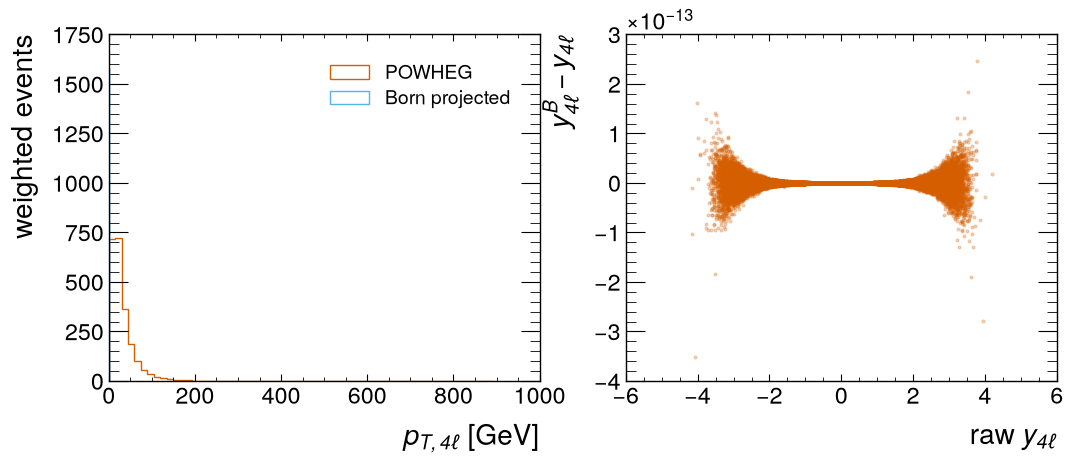

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(events["raw_pt4l"], bins=60, weights=events["weight"], histtype="step", label="POWHEG")
axes[0].hist(events["born_pt4l"], bins=60, weights=events["weight"], histtype="step", label="Born projected")
axes[0].set(xlabel=r"$p_{T,4\ell}$ [GeV]", ylabel="weighted events")
axes[0].legend()
axes[1].scatter(events["raw_y4l"], events["born_y4l"] - events["raw_y4l"], s=4, alpha=0.25)
axes[1].set(xlabel=r"raw $y_{4\ell}$", ylabel=r"$y_{4\ell}^{B}-y_{4\ell}$")
#fig.tight_layout()

## 3. Angular and differential variables

In the Born-projected four-lepton rest frame, the local $\hat z_i$ axis follows $Z_i$. The $\hat y_i$ axis is normal to the beam--$Z_i$ production plane and $\hat x_i=\hat y_i\times\hat z_i$. After boosting the positively charged lepton into its parent-$Z$ rest frame, its direction defines $\Omega_i=(\theta_i,\phi_i)$.

The reader also supplies the usual variables $m_{Z_1}$, $m_{Z_2}$, $m_{ZZ}$, $\cos\theta^*$, $\Phi$, $\Phi_1$, and $\Psi=\Phi_1+\Phi/2$ (wrapped to $[-\pi,\pi)$). Here $Z_1$ is always the dimuon system. At exactly collinear production, an azimuthal origin is mathematically undefined; the record flags this measure-zero case.

,m_Z1,m_Z2,m_ZZ,cos_theta_star,frame_degenerate,standard_angles_degenerate
count,500000.000000,500000.000000,500000.000000,500000.000000,500000,500000
unique,NaN,NaN,NaN,NaN,1,1
top,NaN,NaN,NaN,NaN,False,False
freq,NaN,NaN,NaN,NaN,500000,500000
mean,91.019820,90.890983,249.132762,-0.000734,NaN,NaN
std,5.922283,6.830136,62.797177,0.712816,NaN,NaN
min,0.211403,-0.001994,32.572258,-1.000000,NaN,NaN
25%,89.990154,89.978405,204.469740,-0.724356,NaN,NaN
50%,91.194607,91.190723,231.020610,-0.000867,NaN,NaN
75%,92.390547,92.386199,275.625281,0.722372,NaN,NaN


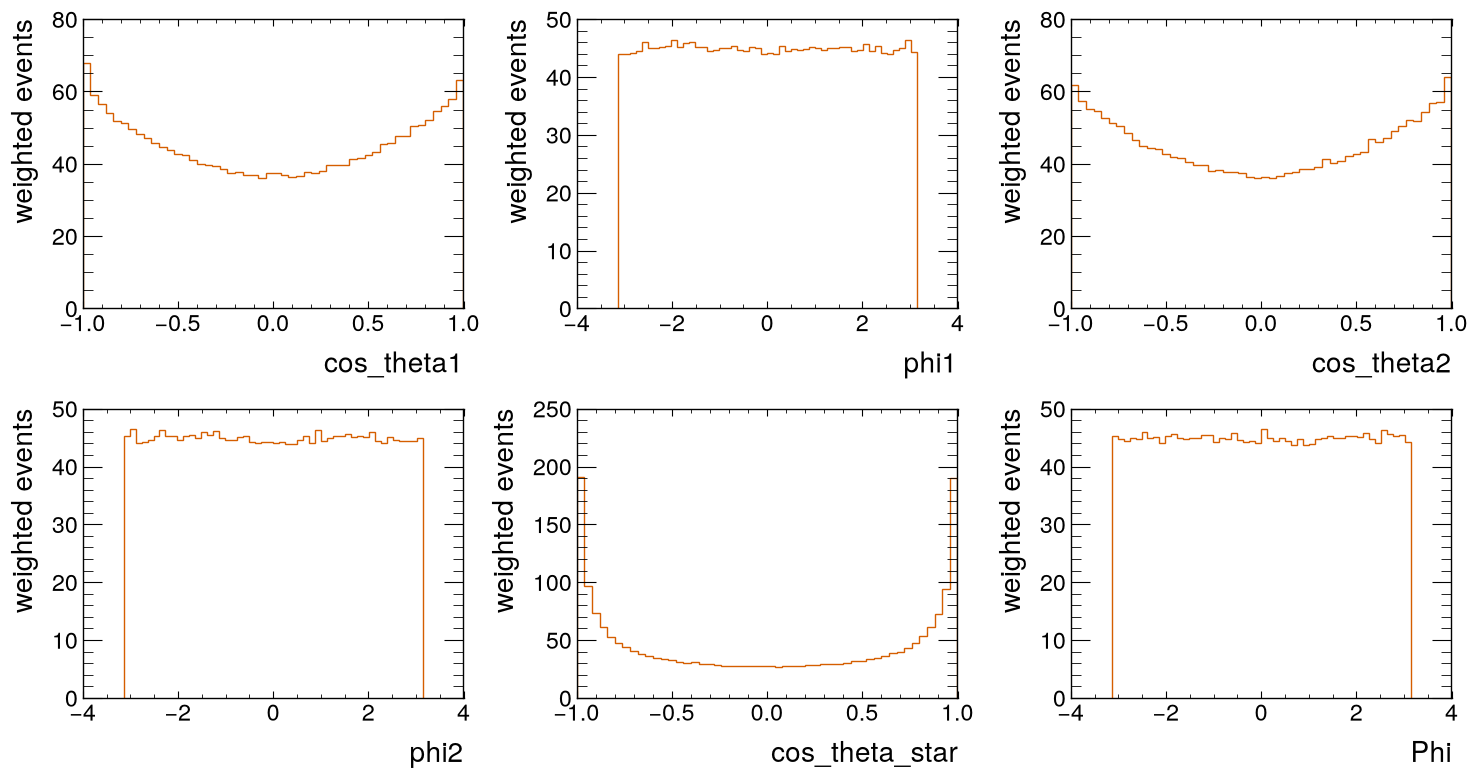

In [7]:
angle_columns = ["cos_theta1", "phi1", "cos_theta2", "phi2", "cos_theta_star", "Phi"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, column in zip(axes.flat, angle_columns):
    axis.hist(events[column].dropna(), bins=50, weights=events.loc[events[column].notna(), "weight"], histtype="step")
    axis.set(xlabel=column, ylabel="weighted events")
fig.tight_layout()

events[["m_Z1", "m_Z2", "m_ZZ", "cos_theta_star", "frame_degenerate", "standard_angles_degenerate"]].describe(include="all")

## 4. Harmonic projection and the $4\pi$ convention

We use

$$p(\Omega_1,\Omega_2,x)=\frac{1}{4\pi}\sum_{\alpha\preceq\beta}\mathcal S_{\alpha\beta}(x)\,\mathcal Y^{(+)}_{\alpha\beta}(\Omega_1,\Omega_2).$$

For an orthonormal basis, multiplication by $\mathcal Y^{(+)*}_{\alpha\beta}$ and integration over both solid angles gives

$$\mathcal S_{\alpha\beta}(x)=4\pi\int d\Omega_1d\Omega_2\;\mathcal Y^{(+)*}_{\alpha\beta}(\Omega_1,\Omega_2)\,p(\Omega_1,\Omega_2,x).$$

In particular, $\mathcal Y^{(+)}_{00;00}=1/(4\pi)$, so angular integration returns $\mathcal S_{00;00}(x)$. A direct MC estimator in an $x$ bin is therefore

$$\widehat{\mathcal S}_{\alpha\beta}(\text{bin})=4\pi\sum_{i\in\text{bin}}w_i\,\mathcal Y^{(+)*}_{\alpha\beta}(\Omega_{1,i},\Omega_{2,i}).$$

For complex harmonics we train the real and imaginary components separately.

In [8]:
# Select one component of one symmetrized coefficient.
COEFFICIENT = dict(l1=2, m1=0, l2=2, m2=0, component="real")

h, target, harmonic_bound = angular_target(
    events["theta1"].to_numpy(),
    events["phi1"].to_numpy(),
    events["theta2"].to_numpy(),
    events["phi2"].to_numpy(),
    **COEFFICIENT,
)
events = events.assign(h_target=h, t_target=target)
selected_coefficient_mask = (
    np.isfinite(events["weight"].to_numpy())
    & np.isfinite(events["h_target"].to_numpy())
    & np.isfinite(events["t_target"].to_numpy())
)
selected_removed_count = np.count_nonzero(~selected_coefficient_mask)
if selected_removed_count:
    warnings.warn(
        "Selected coefficient "
        f"{COEFFICIENT} excludes {selected_removed_count}/{len(events)} events "
        f"({selected_removed_count / len(events):.6%}) with non-finite "
        "weight or harmonic values. The master events dataframe is unchanged.",
        RuntimeWarning,
    )
if not np.any(selected_coefficient_mask):
    raise RuntimeError("No finite events remain for the selected coefficient")

valid_h = events.loc[selected_coefficient_mask, "h_target"].to_numpy()
direct_inclusive_coefficient = 4.0 * np.pi * np.sum(
    events.loc[selected_coefficient_mask, "weight"].to_numpy() * valid_h
)
print(f"Analytic harmonic bound M = {harmonic_bound:.8g}")
print(f"Observed finite h range = [{valid_h.min():.8g}, {valid_h.max():.8g}]")
print(f"Integrated direct coefficient = {direct_inclusive_coefficient:.8g}")

Analytic harmonic bound M = 0.39788736
Observed finite h range = [-0.19891064, 0.39778654]
Integrated direct coefficient = 119.4375

/tmp/ipykernel_10391/1849258067.py:19: RuntimeWarning: Selected coefficient {'l1': 2, 'm1': 0, 'l2': 2, 'm2': 0, 'component': 'real'} excludes 1/500000 events (0.000200%) with non-finite weight or harmonic values. The master events dataframe is unchanged.
  warnings.warn(

## 5. Inclusive $S_{\alpha\beta}$ through $\ell_{\max}=3$

Write $\alpha=(\ell_1,m_1)$ and $\beta=(\ell_2,m_2)$. We retain each symmetric basis element exactly once using

$$\alpha\preceq\beta\quad\Longleftrightarrow\quad \ell_1<\ell_2\quad\text{or}\quad(\ell_1=\ell_2\ \text{and}\ m_1\leq m_2).$$

For $0\leq\ell\leq3$ there are $\sum_{\ell=0}^{3}(2\ell+1)=16$ one-particle modes and $16\times17/2=136$ unordered mode pairs. No neural network is needed for the inclusive projection:

$$\widehat S_{\alpha\beta}=4\pi\sum_i w_i\,\mathcal Y^{(+)*}_{\alpha\beta}(\Omega_{1,i},\Omega_{2,i}).$$

The table below retains the raw complex coefficient and its value relative to $S_{00;00}$. The heatmaps show the real and imaginary parts of $S_{\alpha\beta}/S_{00;00}$; the redundant half of the matrix is masked.

/tmp/ipykernel_10391/29318414.py:5: RuntimeWarning: Inclusive projection excluded non-finite events independently for 135/136 coefficients; the removed fraction ranges from 0.000200% to 0.000200% (largest for alpha=(0, 0), beta=(1, -1)).
  inclusive_angular_coefficients(

,alpha_index,beta_index,l1,m1,l2,m2,alpha,beta,S,Re(S),Im(S),S/S0000,Re(S/S0000),Im(S/S0000),abs(S/S0000),valid_fraction,removed_fraction
0,0,0,0,0,0,0,"(0,0)","(0,0)",2245.492689+ 0.000000j,2245.492689,0.000000e+00,1.000000+0.000000j,1.000000e+00,0.000000e+00,1.000000,1.000000,0.000000
1,0,6,0,0,2,0,"(0,0)","(2,0)",529.521034+ 0.000000j,529.521034,0.000000e+00,0.235815+0.000000j,2.358151e-01,0.000000e+00,0.235815,0.999998,0.000002
2,6,6,2,0,2,0,"(2,0)","(2,0)",119.437502+ 0.000000j,119.437502,0.000000e+00,0.053190+0.000000j,5.318989e-02,0.000000e+00,0.053190,0.999998,0.000002
3,5,5,2,-1,2,-1,"(2,-1)","(2,-1)",-35.970960+ 2.515771j,-35.970960,2.515771e+00,-0.016019+0.001120j,-1.601918e-02,1.120365e-03,0.016058,0.999998,0.000002
4,7,7,2,1,2,1,"(2,1)","(2,1)",-35.970960- 2.515771j,-35.970960,-2.515771e+00,-0.016019-0.001120j,-1.601918e-02,-1.120365e-03,0.016058,0.999998,0.000002
5,4,8,2,-2,2,2,"(2,-2)","(2,2)",36.052275- 0.000000j,36.052275,-8.985881e-18,0.016055-0.000000j,1.605540e-02,-4.001741e-21,0.016055,0.999998,0.000002
6,2,2,1,0,1,0,"(1,0)","(1,0)",26.160056+ 0.000000j,26.160056,0.000000e+00,0.011650+0.000000j,1.165003e-02,0.000000e+00,0.011650,0.999998,0.000002
7,6,8,2,0,2,2,"(2,0)","(2,2)",-18.683129+ 1.336519j,-18.683129,1.336519e+00,-0.008320+0.000595j,-8.320281e-03,5.952007e-04,0.008342,0.999998,0.000002
8,4,6,2,-2,2,0,"(2,-2)","(2,0)",-18.683129- 1.336519j,-18.683129,-1.336519e+00,-0.008320-0.000595j,-8.320281e-03,-5.952007e-04,0.008342,0.999998,0.000002
9,0,4,0,0,2,-2,"(0,0)","(2,-2)",-14.229854+ 1.178147j,-14.229854,1.178147e+00,-0.006337+0.000525j,-6.337074e-03,5.246720e-04,0.006359,0.999998,0.000002


,alpha,beta,valid_fraction,removed_fraction
0,"(0,0)","(1,-1)",0.999998,0.000002
1,"(0,0)","(1,0)",0.999998,0.000002
2,"(0,0)","(1,1)",0.999998,0.000002
3,"(0,0)","(2,-2)",0.999998,0.000002
4,"(0,0)","(2,-1)",0.999998,0.000002
...,...,...,...,...
130,"(3,1)","(3,2)",0.999998,0.000002
131,"(3,1)","(3,3)",0.999998,0.000002
132,"(3,2)","(3,2)",0.999998,0.000002
133,"(3,2)","(3,3)",0.999998,0.000002


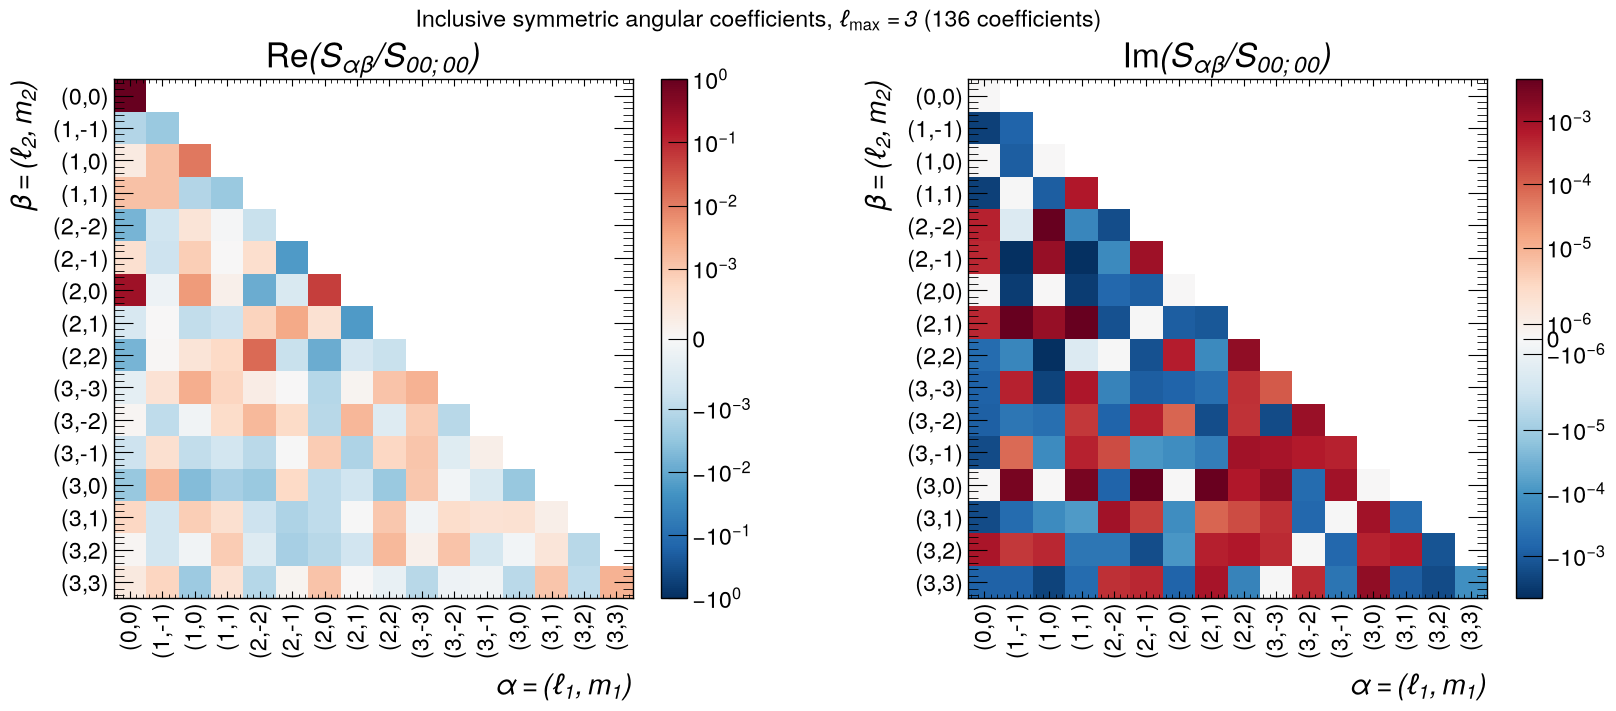

S_00;00 = 2245.492689 (sum of weights = 2245.492689)
Stored 136 coefficients with alpha <= beta

In [9]:
from matplotlib.colors import SymLogNorm

INCLUSIVE_LMAX = 3
inclusive_modes, inclusive_matrix, inclusive_valid_fractions = (
    inclusive_angular_coefficients(
        events["theta1"].to_numpy(),
        events["phi1"].to_numpy(),
        events["theta2"].to_numpy(),
        events["phi2"].to_numpy(),
        events["weight"].to_numpy(),
        l_max=INCLUSIVE_LMAX,
        return_valid_fractions=True,
    )
)

expected_mode_count = (INCLUSIVE_LMAX + 1) ** 2
expected_coefficient_count = expected_mode_count * (expected_mode_count + 1) // 2
assert inclusive_modes == angular_modes(INCLUSIVE_LMAX)
assert len(inclusive_modes) == expected_mode_count
upper_triangle = np.triu_indices(expected_mode_count)
assert np.isfinite(inclusive_valid_fractions[upper_triangle]).all()

s0000_complex = inclusive_matrix[0, 0]
finite_weight_mask = np.isfinite(events["weight"].to_numpy())
sum_weights = events.loc[finite_weight_mask, "weight"].sum()
np.testing.assert_allclose(
    s0000_complex,
    sum_weights,
    rtol=1.0e-12,
    atol=1.0e-12 * max(1.0, abs(sum_weights)),
)
s0000 = float(s0000_complex.real)
if abs(s0000) <= np.finfo(np.float64).tiny:
    raise ZeroDivisionError("S_00;00 is zero, so relative coefficients are undefined")

rows = []
for alpha_index, (l1, m1) in enumerate(inclusive_modes):
    for beta_index in range(alpha_index, len(inclusive_modes)):
        l2, m2 = inclusive_modes[beta_index]
        coefficient = inclusive_matrix[alpha_index, beta_index]
        valid_fraction = inclusive_valid_fractions[alpha_index, beta_index]
        relative = coefficient / s0000
        rows.append(
            {
                "alpha_index": alpha_index,
                "beta_index": beta_index,
                "l1": l1,
                "m1": m1,
                "l2": l2,
                "m2": m2,
                "alpha": f"({l1},{m1})",
                "beta": f"({l2},{m2})",
                "S": coefficient,
                "Re(S)": coefficient.real,
                "Im(S)": coefficient.imag,
                "S/S0000": relative,
                "Re(S/S0000)": relative.real,
                "Im(S/S0000)": relative.imag,
                "abs(S/S0000)": abs(relative),
                "valid_fraction": valid_fraction,
                "removed_fraction": 1.0 - valid_fraction,
            }
        )

inclusive_coefficients = pd.DataFrame(rows)
assert len(inclusive_coefficients) == expected_coefficient_count
display(
    inclusive_coefficients.sort_values("abs(S/S0000)", ascending=False)
    .head(25)
    .reset_index(drop=True)
)
affected_coefficients = inclusive_coefficients.loc[
    inclusive_coefficients["removed_fraction"] > 0.0,
    ["alpha", "beta", "valid_fraction", "removed_fraction"],
].sort_values("removed_fraction", ascending=False)
if not affected_coefficients.empty:
    display(affected_coefficients.reset_index(drop=True))

relative_matrix = inclusive_matrix / s0000
mode_labels = [f"({ell},{m})" for ell, m in inclusive_modes]

fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)
for axis, values, title in zip(
    axes,
    (relative_matrix.real.T, relative_matrix.imag.T),
    (r"$\mathrm{Re}(S_{\alpha\beta}/S_{00;00})$",
     r"$\mathrm{Im}(S_{\alpha\beta}/S_{00;00})$"),
):
    masked_values = np.ma.masked_invalid(values)
    max_abs = float(np.max(np.abs(masked_values.compressed())))
    max_abs = max(max_abs, np.finfo(float).eps)
    image = axis.imshow(
        masked_values,
        origin="upper",
        cmap="RdBu_r",
        norm=SymLogNorm(
            linthresh=max_abs * 1.0e-3,
            linscale=1.0,
            vmin=-max_abs,
            vmax=max_abs,
            base=10,
        ),
        aspect="equal",
    )
    axis.set_xticks(range(len(mode_labels)), labels=mode_labels, rotation=90)
    axis.set_yticks(range(len(mode_labels)), labels=mode_labels)
    axis.set_xlabel(r"$\alpha=(\ell_1,m_1)$")
    axis.set_ylabel(r"$\beta=(\ell_2,m_2)$")
    axis.set_title(title)
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

fig.suptitle(
    rf"Inclusive symmetric angular coefficients, $\ell_{{\max}}={INCLUSIVE_LMAX}$ "
    rf"({expected_coefficient_count} coefficients)"
)
plt.show()

print(f"S_00;00 = {s0000.real:.10g} (sum of weights = {sum_weights:.10g})")
print(f"Stored {len(inclusive_coefficients)} coefficients with alpha <= beta")

## 6. Why the duplicated weighted samples recover the conditional angular moment

For the chosen real component define $h(\Omega)=\operatorname{Re}\mathcal Y^{(+)*}_{\alpha\beta}(\Omega)$ and choose a rigorous $M$ such that $|h|\le M$. Then

$$t(\Omega)=\frac12\left(1+\frac{h(\Omega)}{M}\right)\in[0,1].$$

Duplicate each MC event into a numerator row with weight $w_it_i$ and a denominator row with weight $w_i(1-t_i)$. At fixed $x$, these two weighted measures are

$$A(x)=\int t(\Omega)p(\Omega,x)d\Omega,\qquad B(x)=\int[1-t(\Omega)]p(\Omega,x)d\Omega.$$

Minimizing the weighted binary cross entropy pointwise gives $s^*(x)=A(x)/[A(x)+B(x)]$ and hence $A/B=s^*/(1-s^*)$. Therefore

$$\mathbb E[h\mid x]=M\left(2\frac{A(x)}{A(x)+B(x)}-1\right).$$

`density_ratio_trainer` requires each class to be normalized independently. If $Z_t=\sum_iw_it_i$ and $Z_{1-t}=\sum_iw_i(1-t_i)$, its score yields the normalized-density ratio $r_{\rm norm}=(A/Z_t)/(B/Z_{1-t})$. We must restore

$$\rho(x)=\frac{A(x)}{B(x)}=\frac{Z_t}{Z_{1-t}}r_{\rm norm}(x),\qquad \mathbb E[h\mid x]=M\frac{\rho(x)-1}{\rho(x)+1}.$$

Finally,

$$\mathcal S_{\alpha\beta}(x)=4\pi\frac{d\sigma}{dx}\,\mathbb E[\mathcal Y^{(+)*}_{\alpha\beta}\mid x].$$


In [10]:
FEATURES = ["m_Z1", "m_Z2", "m_ZZ", "cos_theta_star"]
MODEL_VALIDATION_FRACTION = 0.15
EVALUATION_FRACTION = 0.25

coefficient_columns = [*FEATURES, "h_target", "t_target", "weight"]
coefficient_event_mask = np.isfinite(
    events[coefficient_columns].to_numpy(dtype=np.float64)
).all(axis=1)
coefficient_removed_count = np.count_nonzero(~coefficient_event_mask)
if coefficient_removed_count:
    warnings.warn(
        "NN inputs for coefficient "
        f"{COEFFICIENT} exclude {coefficient_removed_count}/{len(events)} events "
        f"({coefficient_removed_count / len(events):.6%}) with non-finite "
        "feature, weight, or target values. The master events dataframe is "
        "unchanged.",
        RuntimeWarning,
    )

coefficient_events = events.loc[coefficient_event_mask].copy()
if len(coefficient_events) < 7:
    raise RuntimeError("Fewer than seven finite events remain for the train/validation/evaluation split")

fit_events, held_out_events = train_test_split(
    coefficient_events,
    test_size=MODEL_VALIDATION_FRACTION + EVALUATION_FRACTION,
    random_state=RNG_SEED,
)
validation_events, evaluation_events = train_test_split(
    held_out_events,
    test_size=EVALUATION_FRACTION / (MODEL_VALIDATION_FRACTION + EVALUATION_FRACTION),
    random_state=RNG_SEED + 1,
)
fit_events = fit_events.reset_index(drop=True)
validation_events = validation_events.reset_index(drop=True)
evaluation_events = evaluation_events.reset_index(drop=True)

# The exported PyTorch/ONNX model accepts float32. Scikit-learn preserves
# input floating dtypes, so cast model features before fitting the scaler.
fit_events = as_float32_features(fit_events, FEATURES)
validation_events = as_float32_features(validation_events, FEATURES)
evaluation_events = as_float32_features(evaluation_events, FEATURES)

training_dataframe, class_normalizations = prepare_weighted_classification(
    fit_events, fit_events["t_target"].to_numpy(), shuffle_seed=RNG_SEED
)
assert training_dataframe[FEATURES].dtypes.eq(np.dtype("float32")).all()
display(pd.Series({
    "fit_source_events": len(fit_events),
    "duplicated_training_rows": len(training_dataframe),
    "model_validation_events": len(validation_events),
    "evaluation_events": len(evaluation_events),
    "Z_t": class_normalizations.z_t,
    "Z_1_minus_t": class_normalizations.z_one_minus_t,
    "odds_correction": class_normalizations.odds_correction,
}))
training_dataframe.groupby("train_labels")["weights_normed"].sum()

/tmp/ipykernel_10391/1809863325.py:11: RuntimeWarning: NN inputs for coefficient {'l1': 2, 'm1': 0, 'l2': 2, 'm2': 0, 'component': 'real'} exclude 1/500000 events (0.000200%) with non-finite feature, weight, or target values. The master events dataframe is unchanged.
  warnings.warn(

fit_source_events           299999.000000
duplicated_training_rows    599998.000000
model_validation_events      75000.000000
evaluation_events           125000.000000
Z_t                            679.935442
Z_1_minus_t                    667.023364
odds_correction                  1.019358
dtype: float64

train_labels
0.0    1.0
1.0    1.0
Name: weights_normed, dtype: float64

The original events are split **before** duplication into fit, model-validation, and final-evaluation samples. `validation_events` selects ensemble members; `evaluation_events` remains untouched until the final closure plot. The toolkit currently performs its own row-level train/holdout split; because the two weighted copies of a source event can land on opposite sides, its built-in holdout diagnostics can be optimistic for this soft-label construction. They are useful for debugging, but the dedicated event-level validation sample is the meaningful model-selection test.

After fitting all members, the next cell computes a class-balanced BCE on `validation_events`. The nominal MC weights remain signed exactly as in training: the two hypotheses use $w_i t_i$ and $w_i(1-t_i)$ and are normalized by their signed sums. With negative weights this is a signed objective rather than a literal non-negative BCE/KL divergence, but it provides a like-for-like comparison across ensemble members. A member is retrained only if its loss exceeds a robust ensemble threshold: the median plus the largest of five scaled median absolute deviations, 5% of the absolute median, and a small numerical floor. This one-sided rule targets clearly failed fits without selecting ordinary seed fluctuations. Non-finite attempts are retried automatically; a slot that still fails after three retries is discarded, and execution continues with the remaining validated members.

2026-07-18 10:10:24 | INFO | Training Logs | Sum of weights of class 0: 0.74963681323679642026-07-18 10:10:24 | INFO | Training Logs | Sum of weights of class 1: 0.74963065649682026-07-18 10:10:24 | INFO | Training Logs | Using swish activation functionGPU available: True (cuda), used: TrueTPU available: False, using: 0 TPU cores/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](h

Epoch    0 | lr = 1.000e-03 | val_loss = 0.692696 | Epoch    0 | lr = 1.000e-03 | val_loss = 0.693210 | Epoch    1 | lr = 1.000e-03 | train_loss = 0.693288 | val_loss = 0.693136 | Epoch    2 | lr = 1.000e-03 | train_loss = 0.693174 | val_loss = 50.230751 | Epoch    3 | lr = 1.000e-03 | train_loss = 13.599514 | val_loss = 50.230751 | Epoch    4 | lr = 1.000e-03 | train_loss = 49.924950 | val_loss = 50.230751 | Epoch    5 | lr = 1.000e-03 | train_loss = 49.925755 | val_loss = 50.230751 | Epoch    6 | lr = 1.000e-03 | train_loss = 49.926449 | val_loss = 50.230751 | Epoch    7 | lr = 1.000e-03 | train_loss = 49.924011 | val_loss = 50.230751 | Epoch    8 | lr = 1.000e-03 | train_loss = 49.924805 | val_loss = 50.230751 | Epoch    9 | lr = 1.000e-05 | train_loss = 49.924938 | val_loss = 50.230751 | Epoch   10 | lr = 1.000e-05 | train_loss = 49.926010 | val_loss = 50.230751 | Epoch   11 | lr = 1.000e-05 | train_loss = 49.923622 | val_loss = 50.230751 | 

2026-07-18 10:11:18 | INFO | Training Logs | Finished Training/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/training/utils.py:91: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0718 10:11:19.053000 10391 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX featuresW0718 10:11:19.585000 10391 site-packages/torch/

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...

/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).

...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...

/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅

,member,attempt,seed,validation_bce,failure,status,acceptance_threshold
0,0,0,20260718,0.693158,None,accepted,0.727802
1,1,0,20270718,0.693132,None,accepted,0.727802
2,2,0,20280718,0.693171,None,accepted,0.727802
3,3,0,20290718,0.693077,None,accepted,0.727802


<Figure size 800x600 with 0 Axes>

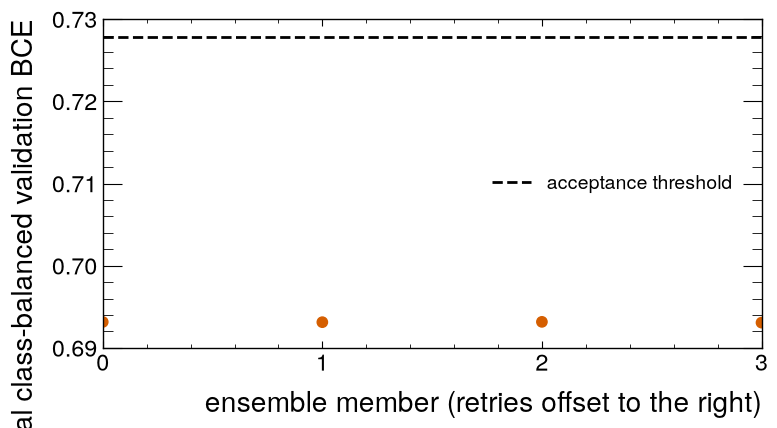

In [11]:
from nsbi_common_utils.training import density_ratio_trainer, predict_with_model

MODELS_DIR = PROJECT_ROOT / "models" / "angular_ratio"
FIGURES_DIR = PROJECT_ROOT / "figures" / "angular_ratio"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ENSEMBLE_SIZE = 4
MAX_MEMBER_RETRIES = 3
LOSS_MAD_SCALE = 5.0
LOSS_MIN_RELATIVE_EXCESS = 0.05
ratio_trainer = [None] * ENSEMBLE_SIZE
ensemble_validation_losses = np.full(ENSEMBLE_SIZE, np.nan)
validation_attempts = []

RUN_MODEL = True  # Set True after the input/projection checks look sensible.
LOAD_TRAINED_MODEL = False

def make_ratio_trainer():
    return density_ratio_trainer(
        dataset=training_dataframe,
        weights=training_dataframe["weights_normed"].to_numpy(),
        training_labels=training_dataframe["train_labels"].to_numpy(),
        features=FEATURES,
        features_scaling=FEATURES,
        sample_name=["t-weighted", "one-minus-t-weighted"],
        output_name="angular_moment",
        path_to_figures=f"{FIGURES_DIR}/",
        path_to_models=f"{MODELS_DIR}/",
        use_log_loss=False,
    )

def train_and_validate_member(member_index, attempt, *, load_existing=False):
    seed = RNG_SEED + 10_000 * member_index + attempt
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    trainer = make_ratio_trainer()
    try:
        trainer.train(
            hidden_layers=5,
            neurons=1024,
            number_of_epochs=50,
            batch_size=1024,
            learning_rate=1e-3,
            scalerType="MinMax",
            ensemble_index=member_index,
            verbose=1,
            rnd_seed=seed,
            holdout_split=0.25,
            validation_split=0.2,
            callback_patience=10,
            num_workers=4,
            load_trained_models=load_existing,
            calibration=False,
            type_of_calibration="histogram",
            recalibrate_output=True,
            num_bins_cal=100,
        )
        scores = predict_with_model(
            validation_events[FEATURES],
            scaler=trainer.scaler,
            model=trainer.model_NN,
            calibration_model=None,
            use_log_loss=trainer.use_log_loss,
        )
        loss = class_balanced_validation_bce(
            scores,
            validation_events["t_target"].to_numpy(),
            validation_events["weight"].to_numpy(),
        )
        if not np.isfinite(loss):
            raise ValueError(f"non-finite validation BCE: {loss}")
    except Exception as error:
        failure = f"{type(error).__name__}: {error}"[:500]
        warnings.warn(
            f"Ensemble member {member_index}, attempt {attempt}, failed model "
            f"validation ({failure}). It will be treated as an infinite-loss "
            "attempt and retried when capacity remains.",
            RuntimeWarning,
        )
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return None, np.inf, seed, failure
    return trainer, loss, seed, None

if RUN_MODEL:
    attempt_numbers = np.zeros(ENSEMBLE_SIZE, dtype=int)
    discarded_members = np.zeros(ENSEMBLE_SIZE, dtype=bool)
    current_audit_rows = np.full(ENSEMBLE_SIZE, -1, dtype=int)

    for member_index in range(ENSEMBLE_SIZE):
        trainer, loss, seed, failure = train_and_validate_member(
            member_index, 0, load_existing=LOAD_TRAINED_MODEL
        )
        ratio_trainer[member_index] = trainer
        ensemble_validation_losses[member_index] = loss
        validation_attempts.append(
            dict(
                member=member_index,
                attempt=0,
                seed=seed,
                validation_bce=loss,
                failure=failure,
                status="pending",
            )
        )
        current_audit_rows[member_index] = len(validation_attempts) - 1

    while np.any(~discarded_members):
        active_members = np.flatnonzero(~discarded_members)
        rejected_active, acceptance_threshold = validation_loss_outlier_mask(
            ensemble_validation_losses[active_members],
            mad_scale=LOSS_MAD_SCALE,
            min_relative_excess=LOSS_MIN_RELATIVE_EXCESS,
        )
        rejected_members = active_members[rejected_active]

        for member_index, is_rejected in zip(active_members, rejected_active):
            row = validation_attempts[current_audit_rows[member_index]]
            row["acceptance_threshold"] = acceptance_threshold
            row["status"] = "rejected" if is_rejected else "accepted"
        if len(rejected_members) == 0:
            break

        for member_index in rejected_members:
            previous_loss = ensemble_validation_losses[member_index]
            if attempt_numbers[member_index] >= MAX_MEMBER_RETRIES:
                discarded_members[member_index] = True
                ratio_trainer[member_index] = None
                validation_attempts[current_audit_rows[member_index]]["status"] = "discarded"
                warnings.warn(
                    f"Discarding ensemble member {member_index}: validation BCE "
                    f"{previous_loss:.6g} did not pass after "
                    f"{MAX_MEMBER_RETRIES} retries. Execution will continue with "
                    "the remaining validated members.",
                    RuntimeWarning,
                )
                continue

            attempt_numbers[member_index] += 1
            attempt = int(attempt_numbers[member_index])
            warnings.warn(
                f"Retraining ensemble member {member_index} (attempt {attempt}) after "
                f"validation BCE {previous_loss:.6g}; current threshold is "
                f"{acceptance_threshold:.6g}.",
                RuntimeWarning,
            )
            trainer, loss, seed, failure = train_and_validate_member(
                member_index, attempt
            )
            ratio_trainer[member_index] = trainer
            ensemble_validation_losses[member_index] = loss
            validation_attempts.append(
                dict(
                    member=member_index,
                    attempt=attempt,
                    seed=seed,
                    validation_bce=loss,
                    failure=failure,
                    status="pending",
                )
            )
            current_audit_rows[member_index] = len(validation_attempts) - 1

    validated_member_indices = [
        member_index
        for member_index in range(ENSEMBLE_SIZE)
        if (
            not discarded_members[member_index]
            and ratio_trainer[member_index] is not None
            and np.isfinite(ensemble_validation_losses[member_index])
        )
    ]
    validated_ratio_trainers = [
        ratio_trainer[member_index] for member_index in validated_member_indices
    ]
    MODEL_VALIDATION_PASSED = len(validated_ratio_trainers) > 0
    if len(validated_ratio_trainers) < ENSEMBLE_SIZE:
        warnings.warn(
            f"Validated {len(validated_ratio_trainers)}/{ENSEMBLE_SIZE} ensemble "
            "members. Downstream diagnostics and closure will use only these members.",
            RuntimeWarning,
        )

    validation_audit = pd.DataFrame(validation_attempts)
    display(validation_audit)
    fig, axis = plt.subplots(figsize=(8, 4.5))
    finite_audit = validation_audit[np.isfinite(validation_audit["validation_bce"])].copy()
    colors = finite_audit["status"].map(
        {"accepted": "C0", "rejected": "C3", "discarded": "0.4"}
    )
    axis.scatter(
        finite_audit["member"] + 0.08 * finite_audit["attempt"],
        finite_audit["validation_bce"],
        c=colors,
        s=55,
    )
    if np.isfinite(acceptance_threshold):
        axis.axhline(acceptance_threshold, color="black", linestyle="--", label="acceptance threshold")
    axis.set(
        xlabel="ensemble member (retries offset to the right)",
        ylabel="external class-balanced validation BCE",
        xticks=np.arange(ENSEMBLE_SIZE),
    )
    if np.isfinite(acceptance_threshold):
        axis.legend()
    fig.tight_layout()
else:
    validated_member_indices = []
    validated_ratio_trainers = []
    MODEL_VALIDATION_PASSED = False
    print("Training is disabled. Set RUN_MODEL=True and rerun this cell.")

/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:66: RuntimeWarning: invalid value encountered in divide
  hist_ratio = hist_num / (hist_den + hist_num)
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:68: RuntimeWarning: divide by zero encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in multiply
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/

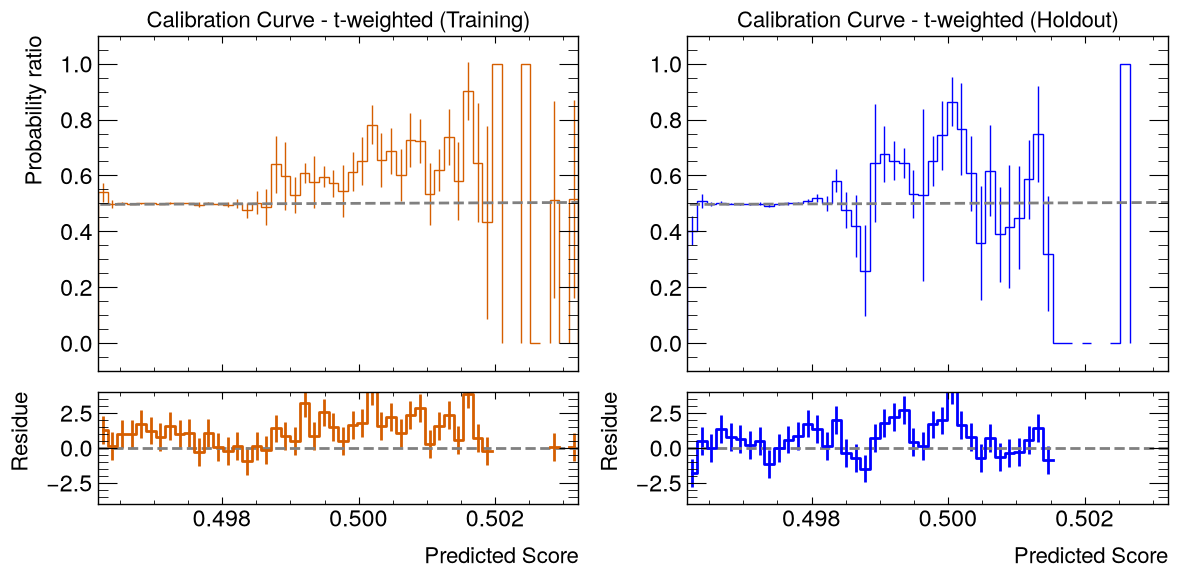

<Figure size 800x600 with 0 Axes>

In [12]:
if MODEL_VALIDATION_PASSED:
    trainer_to_plot = validated_ratio_trainers[0]
    ensemble_index_to_plot = validated_member_indices[0]
    trainer_to_plot.make_calib_plots(
        observable="score", nbins=50, ensemble_index=ensemble_index_to_plot
    )
else:
    print("No validated ensemble member is available for calibration plots.")

/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:319: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/home/rcoelhol/of

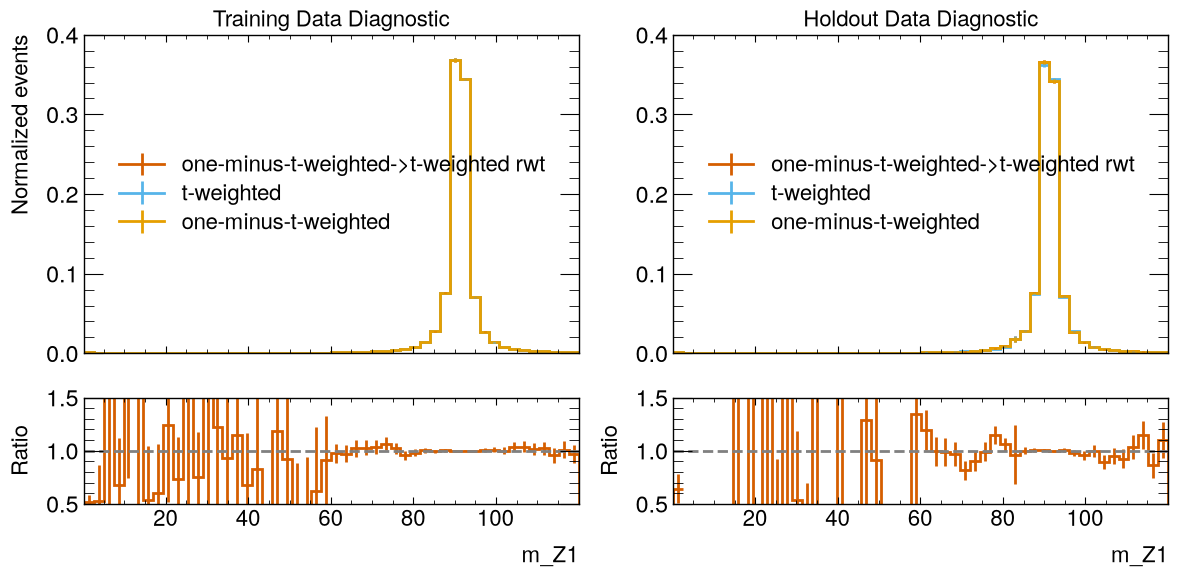

/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/home/rcoelhol/o

<Figure size 800x600 with 0 Axes>

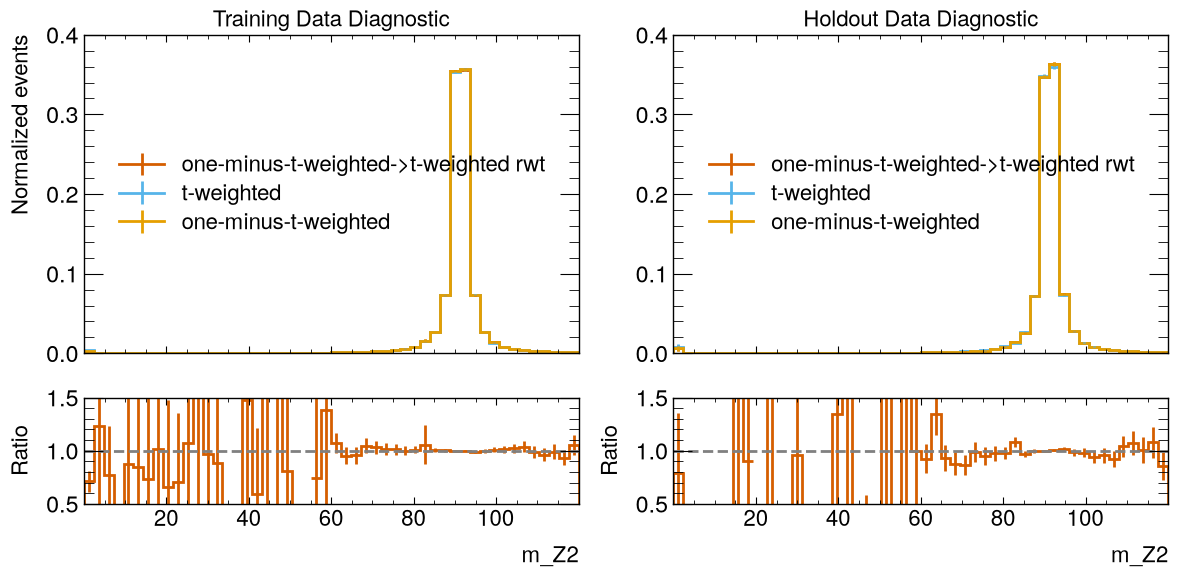

/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:319: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/home/rcoelhol/offshell_angular_coefficients/.pixi/envs/analysis-gpu/lib/python3.12/site-packages/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err

<Figure size 800x600 with 0 Axes>

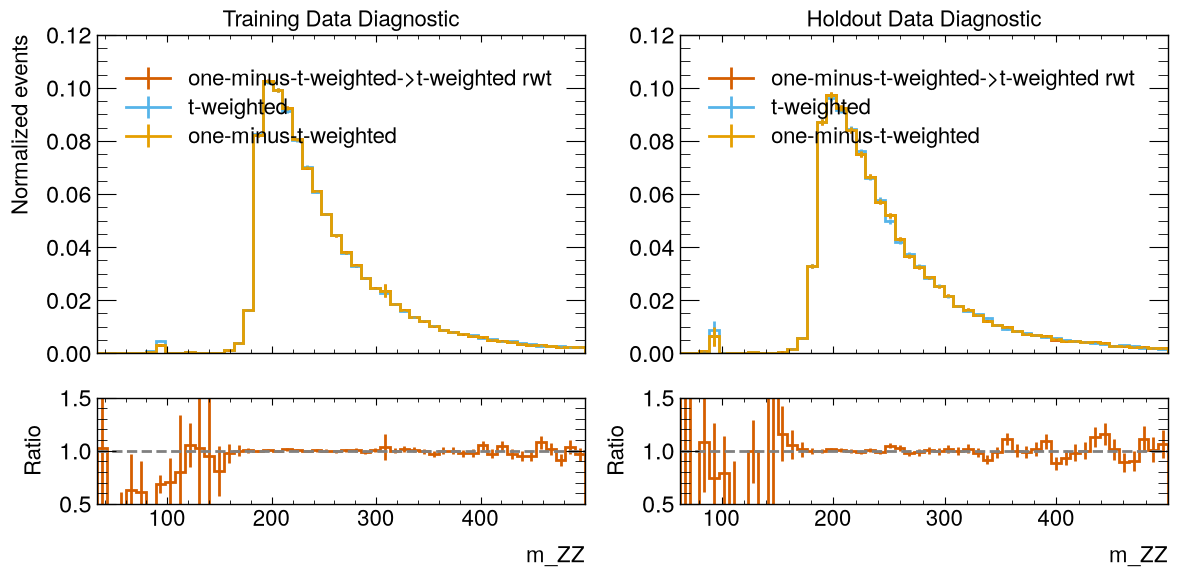

<Figure size 800x600 with 0 Axes>

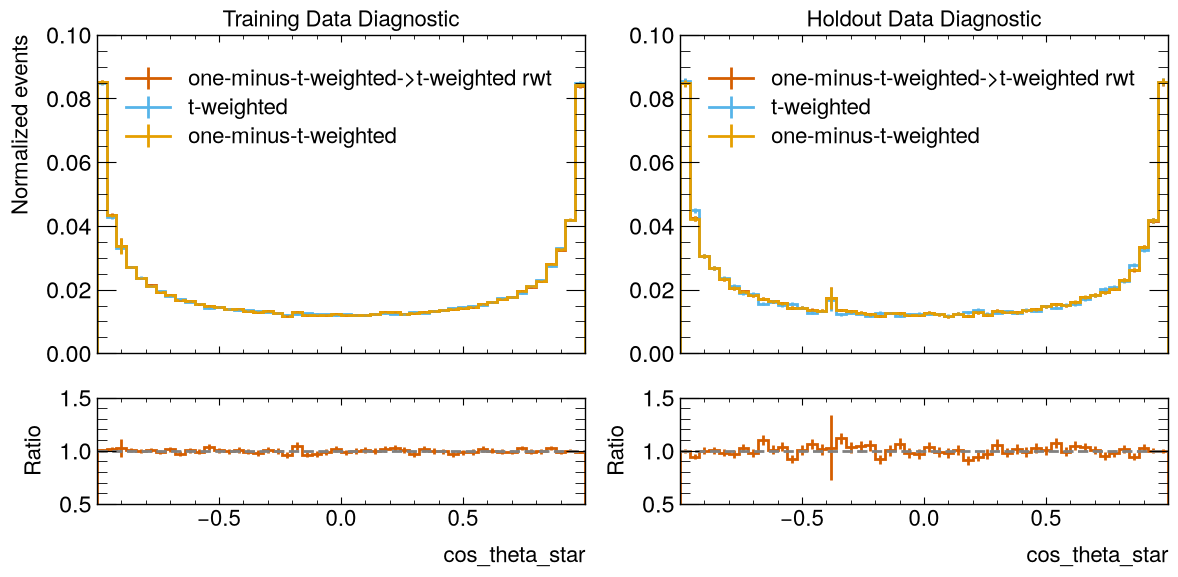

<Figure size 800x600 with 0 Axes>

In [13]:
if MODEL_VALIDATION_PASSED:
    trainer_to_plot.make_reweighted_plots(FEATURES, "linear", 50)
else:
    print("No validated ensemble member is available for reweighted plots.")

## 7. Recover the moment and close the differential coefficient

The toolkit prediction is a classifier score $s_{\rm norm}$. We first form $r_{\rm norm}=s_{\rm norm}/(1-s_{\rm norm})$, restore the class-normalization factor, and recover $\widehat{\mathbb E[h\mid x]}$. The closure comparison below uses only the untouched event-level evaluation sample.

In [14]:
if MODEL_VALIDATION_PASSED:
    from nsbi_common_utils.training import predict_with_model

    member_scores = np.stack([
        np.clip(
            np.asarray(
                predict_with_model(
                    evaluation_events[FEATURES],
                    scaler=trainer.scaler,
                    model=trainer.model_NN,
                    calibration_model=None,
                    use_log_loss=trainer.use_log_loss,
                )
            ),
            1.0e-8,
            1.0 - 1.0e-8,
        )
        for trainer in validated_ratio_trainers
    ])
    member_normalized_ratios = member_scores / (1.0 - member_scores)

    # Match the toolkit's default ensemble convention: average density ratios,
    # rather than scores, before applying the class-normalization correction.
    normalized_ratio = np.mean(member_normalized_ratios, axis=0)
    score_norm = normalized_ratio / (1.0 + normalized_ratio)
    eta_hat, h_hat = recover_conditional_moment(
        normalized_ratio, class_normalizations, harmonic_bound
    )
    evaluation_events = evaluation_events.assign(
        score_norm=score_norm, eta_hat=eta_hat, h_hat=h_hat
    )
    display(evaluation_events[[*FEATURES, "h_target", "h_hat"]].head())
else:
    print("No validated ensemble member is available for closure.")

,m_Z1,m_Z2,m_ZZ,cos_theta_star,h_target,h_hat
0,90.297165,89.124619,205.818283,0.336661,0.046833,0.003628
1,91.542572,92.983223,259.692413,0.349478,-0.109556,0.003411
2,83.992439,83.410225,330.165070,0.948157,0.005942,0.002802
3,89.860023,90.990219,204.676086,0.215984,-0.056140,0.003757
4,0.365938,92.650612,106.036751,-0.782706,0.044614,0.044805


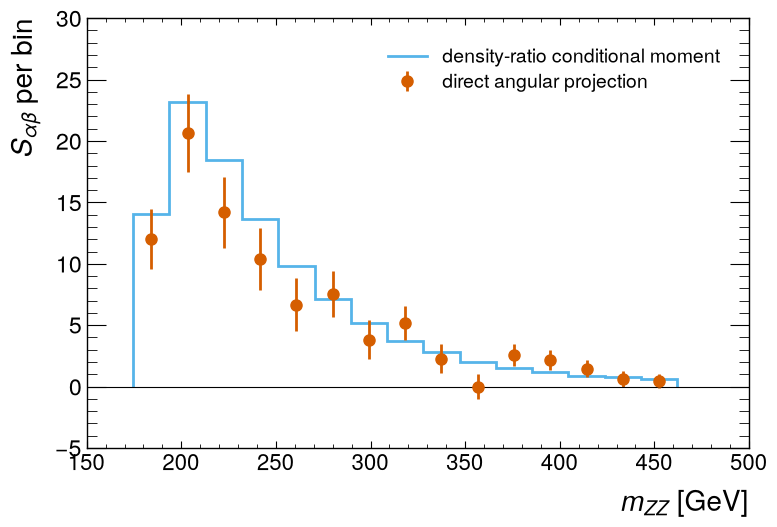

In [15]:
if MODEL_VALIDATION_PASSED:
    mzz = evaluation_events["m_ZZ"].to_numpy()
    bins = np.linspace(np.quantile(mzz, 0.01), np.quantile(mzz, 0.99), 16)
    centers = 0.5 * (bins[1:] + bins[:-1])
    # Undo the random evaluation subsampling in expectation.
    evaluation_weights = (
        evaluation_events["weight"].to_numpy()
        * len(events) / len(evaluation_events)
    )
    direct, _ = np.histogram(
        mzz, bins=bins, weights=4.0*np.pi*evaluation_weights*evaluation_events["h_target"]
    )
    learned, _ = np.histogram(
        mzz, bins=bins, weights=4.0*np.pi*evaluation_weights*evaluation_events["h_hat"]
    )
    direct_variance, _ = np.histogram(
        mzz, bins=bins, weights=(4.0*np.pi*evaluation_weights*evaluation_events["h_target"])**2
    )

    fig, axis = plt.subplots(figsize=(8, 5.5))
    axis.errorbar(centers, direct, yerr=np.sqrt(direct_variance), fmt="o", label="direct angular projection")
    axis.stairs(learned, bins, label="density-ratio conditional moment", linewidth=2)
    axis.axhline(0.0, color="black", linewidth=0.8)
    axis.set(xlabel=r"$m_{ZZ}$ [GeV]", ylabel=r"$S_{\alpha\beta}$ per bin")
    axis.legend()
    fig.tight_layout()
else:
    print("No validated ensemble member is available for the closure plot.")

### Required validation before physics use

Repeat the closure for every real and imaginary component retained in the expansion, vary architecture and random seeds, and check stability versus LHE statistics and binning. Validate angle signs against a small hand-checked sample. For a final result, use event-grouped cross-validation or independently generated samples and propagate finite-MC, training, and model-ensemble uncertainties. The direct points above include only their finite-evaluation-sample weighted variance; the learned curve does not yet include model uncertainty.